### Phase 10: Robustness Experiments
**Objective**: Apply controlled degradation (blur, noise, contrast, rotation) to a clean document and measure the effect on OCR and Layout detection.

In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.preprocessing.pipeline import render_pdf_page, to_grayscale, apply_clahe, otsu_threshold, preprocess_document
from src.ocr.ocr_engine import extract_text_and_boxes

def add_gaussian_blur(img):
    return cv2.GaussianBlur(img, (15, 15), 0)

def add_salt_pepper_noise(img):
    prob = 0.02
    output = np.copy(img)
    thres = 1 - prob 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            rdn = np.random.random()
            if rdn < prob:
                output[i][j] = 0
            elif rdn > thres:
                output[i][j] = 255
    return output

def reduce_contrast(img):
    # Convert to YUV, scale down the U and V channels, convert back
    img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img_yuv[:,:,0] = img_yuv[:,:,0] * 0.4 # Reduce brightness channel
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

def rotate_image(img):
    rows, cols, _ = img.shape
    M = cv2.getRotationMatrix2D((cols/2, rows/2), 5, 1) # 5 degree rotation
    return cv2.warpAffine(img, M, (cols, rows))

print("Degradation functions ready.")

Degradation functions ready.


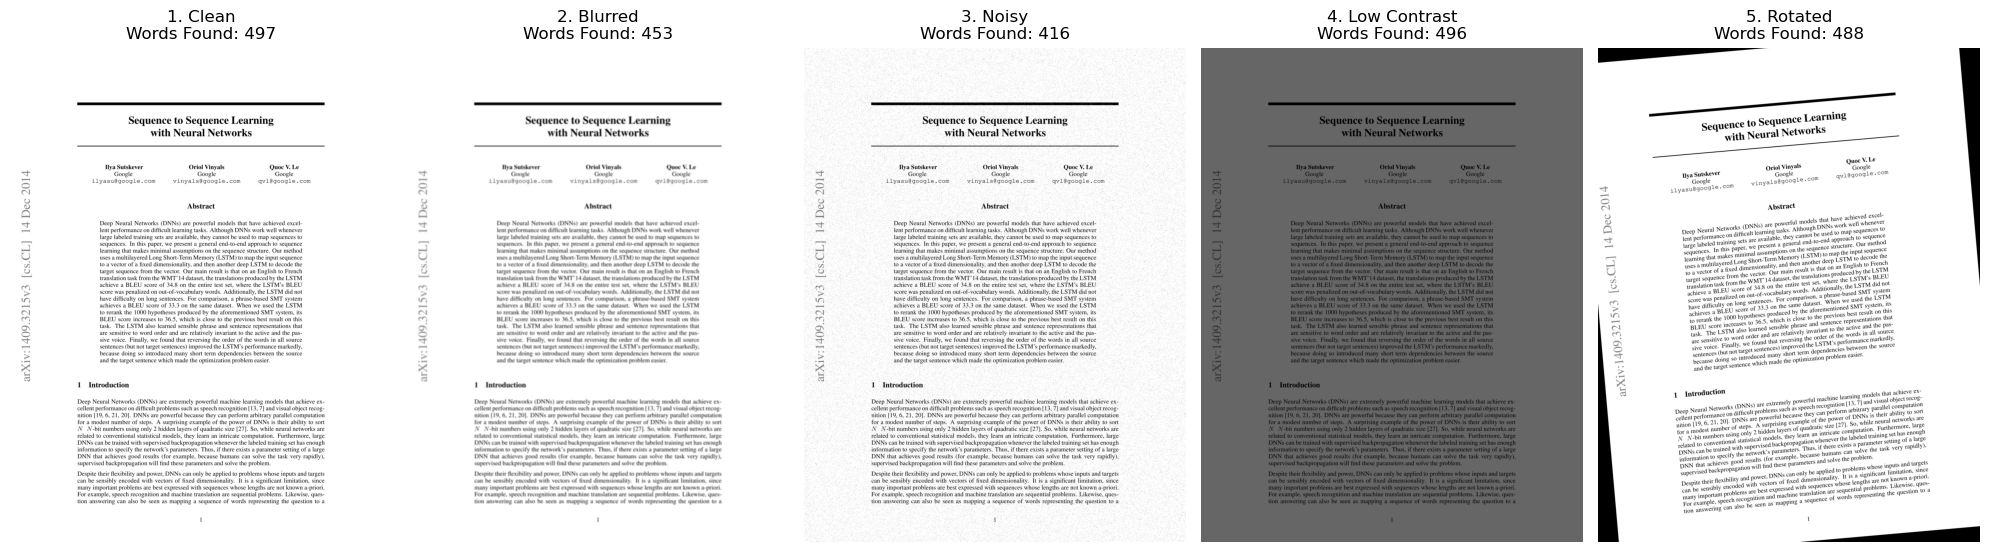

In [4]:
# 1. Load the clean document
pdf_path = "../data/raw/seq-2-seq.pdf"
clean_img = render_pdf_page(pdf_path, page_num=0, dpi=300)

# 2. Generate degraded versions
degraded_images = {
    "1. Clean": clean_img,
    "2. Blurred": add_gaussian_blur(clean_img),
    "3. Noisy": add_salt_pepper_noise(clean_img),
    "4. Low Contrast": reduce_contrast(clean_img),
    "5. Rotated": rotate_image(clean_img)
}

# 3. Run OCR on each version and count valid words
plt.figure(figsize=(20, 8))

for i, (name, img) in enumerate(degraded_images.items()):
    # Run OCR
    ocr_tokens = extract_text_and_boxes(img)
    valid_words = [t for t in ocr_tokens if len(t['text']) > 1 and t['confidence'] > 0.5]
    
    # Plot the image and word count
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{name}\nWords Found: {len(valid_words)}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

Noisy (Raw): 416 words
Noisy (Preprocessed): 493 words

Blurred (Raw): 453 words
Blurred (Preprocessed): 417 words


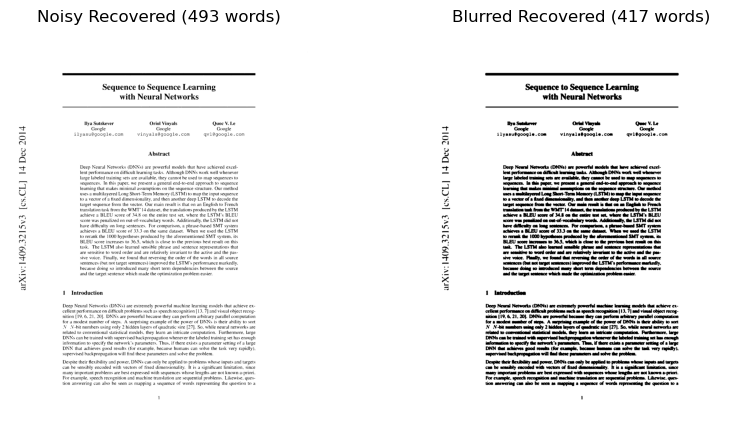

In [5]:
# Let's take the Noisy and Blurred images, apply our preprocessing pipeline, and re-run OCR

def recover_with_preprocessing(img):
    """Applies our Phase 1 pipeline to a degraded image."""
    gray = to_grayscale(img)
    
    # Median filtering is excellent for Salt-and-Pepper noise!
    denoised = cv2.medianBlur(gray, 3)
    
    # CLAHE for contrast, Otsu for thresholding
    final_img = otsu_threshold(apply_clahe(denoised))
    return final_img

# 1. Test on Noisy Image
noisy_img = degraded_images["3. Noisy"]
recovered_noisy = recover_with_preprocessing(noisy_img)
noisy_tokens = extract_text_and_boxes(recovered_noisy)
valid_noisy_words = [t for t in noisy_tokens if len(t['text']) > 1 and t['confidence'] > 0.5]

print(f"Noisy (Raw): 416 words")
print(f"Noisy (Preprocessed): {len(valid_noisy_words)} words\n")

# 2. Test on Blurred Image
# Note: If an image is already blurred, we can't "unblur" it easily, 
# but thresholding can sometimes help separate merged characters.
blurred_img = degraded_images["2. Blurred"]
recovered_blurred = recover_with_preprocessing(blurred_img)
blurred_tokens = extract_text_and_boxes(recovered_blurred)
valid_blurred_words = [t for t in blurred_tokens if len(t['text']) > 1 and t['confidence'] > 0.5]

print(f"Blurred (Raw): 453 words")
print(f"Blurred (Preprocessed): {len(valid_blurred_words)} words")

# Visualize the recovery
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(recovered_noisy, cmap='gray')
plt.title(f"Noisy Recovered ({len(valid_noisy_words)} words)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(recovered_blurred, cmap='gray')
plt.title(f"Blurred Recovered ({len(valid_blurred_words)} words)")
plt.axis('off')
plt.show()